# A — Small Impact Events: Temperature and Pressure Conditions Analysis

This notebook establishes the **thermal and barometric conditions** associated with 
impact events during planetary accretion by analyzing collision-induced melting:

**Key steps:**
1. Load N-body accretion history with collision records
2. Initialize ImpactEventProcessor to classify impact events
   - **Small impacts:** P = 0.6 × P_CMB (local mantle melting)
   - **Global melting events:** System-wide thermal effects
3. Update global melting process evolution (duration ~ 5 Myr)
4. Extract equilibrium pressure (P_equil) and mass evolution at impact moments
5. Visualize temporal evolution of:
   - Planetary mass at each impact event
   - Equilibrium pressure conditions during accretion
6. Color-code by event type (small → black, global → orange)
7. Export processed event data with classification to Excel

**Output:** `./Tables/{Model}_small_impact.xlsx`

> **Key assumptions:**
> - Small impact pressure = 0.6 × CMB pressure (empirical fit)
> - Global melting duration = 5 Myr (post-impact thermal relaxation)
> - Equilibrium pressure = hydrostatic pressure at impact depth
>
> **Input:** `../Accrection/Tables/{Model}_collision_history.xlsx` (multi-sheet accretion history)  
> **Output:** Classified impact events with P-T conditions

**Physical context:**

The accretion process produces two types of thermal events:

$$\text{Event}_{\text{type}} = \begin{cases}
\text{Small impact} & \text{if } P_{\text{impact}} = 0.6 P_{\text{CMB}} \\
\text{Global melting} & \text{if thermal wave affects entire mantle}
\end{cases}$$

Each collision generates a **pressure pulse** that:
- Induces local decompression melting
- May trigger global magma ocean if energy > threshold
- Evolves over ~5 Myr as planet re-equilibrates

This notebook tracks when and where these thermal events occur in the accretion history.

In [1]:
# ============================================================================
# SETUP & CONFIGURATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
from matplotlib.lines import Line2D
import pathlib

sys.path.append('../../src')
import accrediff as ad

# ── Plot style (Nature-style) ────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",       # 衬线字体
    "font.size": 12,              # 主体字体大小
    "axes.linewidth": 1,          # 坐标轴线宽
    "axes.labelsize": 14,         # 坐标轴标签大小
    "xtick.labelsize": 12,        # x 轴刻度字体
    "ytick.labelsize": 12,        # y 轴刻度字体
    "xtick.direction": "in",      # 刻度线朝内
    "ytick.direction": "in",
    "xtick.top": False,           # 去掉上方刻度
    "ytick.right": False,         # 去掉右侧刻度
    "figure.dpi": 300             # 提高分辨率
})

# ── Impact event configuration ───────────────────────────────────
config = {
    'p_ratio': 0.6,               # Small impacts: P = 0.6 × P_CMB
    'Mtotal': 0.1,                # Total mass parameter
    'ratio': [0.1, 0.5],          # Impact magnitude ratios
    'duration': 5,                # Global melting duration (Myr)
}

print("✅ Setup complete.")
print(f"Configuration:")
print(f"  Small impact pressure  : {config['p_ratio']} × P_CMB")
print(f"  Global melting duration: {config['duration']} Myr")
print()

✅ Setup complete.
Configuration:
  Small impact pressure  : 0.6 × P_CMB
  Global melting duration: 5 Myr



---
## 1. Load Accretion History Data

Load multi-sheet Excel file containing collision records and 
orbital/thermal evolution of planetary bodies.

**Key columns expected:**
- `Time` — simulation time (Myr)
- `Mass` — body mass (Earth masses)
- `P_equil` — equilibrium pressure (GPa)
- `target_id` — final planet ID for tracking
- Other columns: orbital elements, temperature, etc.

In [2]:
# ============================================================================
# SECTION 1: LOAD ACCRETION HISTORY
# ============================================================================

Model = 'note_02'
data_name = Model+'_collision_history.xlsx'
base_path = '../Accrection/Tables/'
Path_accretion_history = os.path.join(base_path, data_name)

# ── Load all sheets from Excel ───────────────────────────────────
if not os.path.exists(Path_accretion_history):
    raise FileNotFoundError(f"Input file not found: {Path_accretion_history}")

D = pd.read_excel(Path_accretion_history, sheet_name=None)
title = Path_accretion_history[21:28]  # Extract filename for titles

print(f"✓ Loaded accretion history: {Path_accretion_history}")
print(f"  Available sheets: {len(D)}")
print(f"  Sheet names: {list(D.keys())}")
print()

✓ Loaded accretion history: ../Accrection/Tables/note_02_collision_history.xlsx
  Available sheets: 3
  Sheet names: ['planets_1', 'planets_2', 'planets_3']



---
## 2. Classify and Mark Impact Events

For each dataset, initialize the ImpactEventProcessor to:
1. Identify collision events (CE = collision event)
2. Classify as **small** (local melting) or **global** (system-wide)
3. Update thermal effects of global melting (~5 Myr recovery)

**Event classification:**
- **Small impact:** Pressure = 0.6 × CMB pressure, localized effects
- **Global melting:** Exceeds threshold, affects entire planet

In [3]:
# ============================================================================
# SECTION 2: CLASSIFY IMPACT EVENTS
# ============================================================================

data_dict = {}

print(f"✓ Processing impact events with ImpactEventProcessor:")
print()

for key in D.keys():
    df = D[key]
    
    # ── Initialize processor ─────────────────────────────────────
    processor = ad.ImpactEventProcessor(
        df, 
        p_ratio=config['p_ratio'],        # Small impacts P = 0.6 × P_cmb
        Mtotal=config['Mtotal'],          # Total mass parameter
        ratio=config['ratio']             # Impact magnitude ratios
    )
    
    # ── Extract marked collision events ──────────────────────────
    df_CE = processor.df_CE
    
    # ── Update global melting process influence ──────────────────
    # Updates thermal effects of global melting over ~5 Myr recovery period
    df_CE = processor.update_global_melting_process(duration=config['duration'])
    
    # ── Store processed data ─────────────────────────────────────
    data_dict[key] = df_CE
    
    # ── Report statistics ────────────────────────────────────────
    n_small = (df_CE['events'] == 'small').sum()
    n_global = (df_CE['events'] == 'global').sum()
    
    print(f"  {key:20s}: {len(df_CE):4d} total events | " +
          f"small: {n_small:3d} | global: {n_global:3d}")

print()

✓ Processing impact events with ImpactEventProcessor:

  planets_1           :  142 total events | small: 139 | global:   3
  planets_2           :   96 total events | small:  84 | global:  12
  planets_3           :   26 total events | small:  26 | global:   0



---
## 3a. Visualize Mass Evolution with Impact Events

Plot planetary mass over time, color-coded by impact event type:
- **Black dots** = Small impact events (local melting)
- **Orange dots** = Global melting events (system-wide)
- **Grey line** = Continuous mass evolution

This shows when major impact events occurred relative to planetary growth.

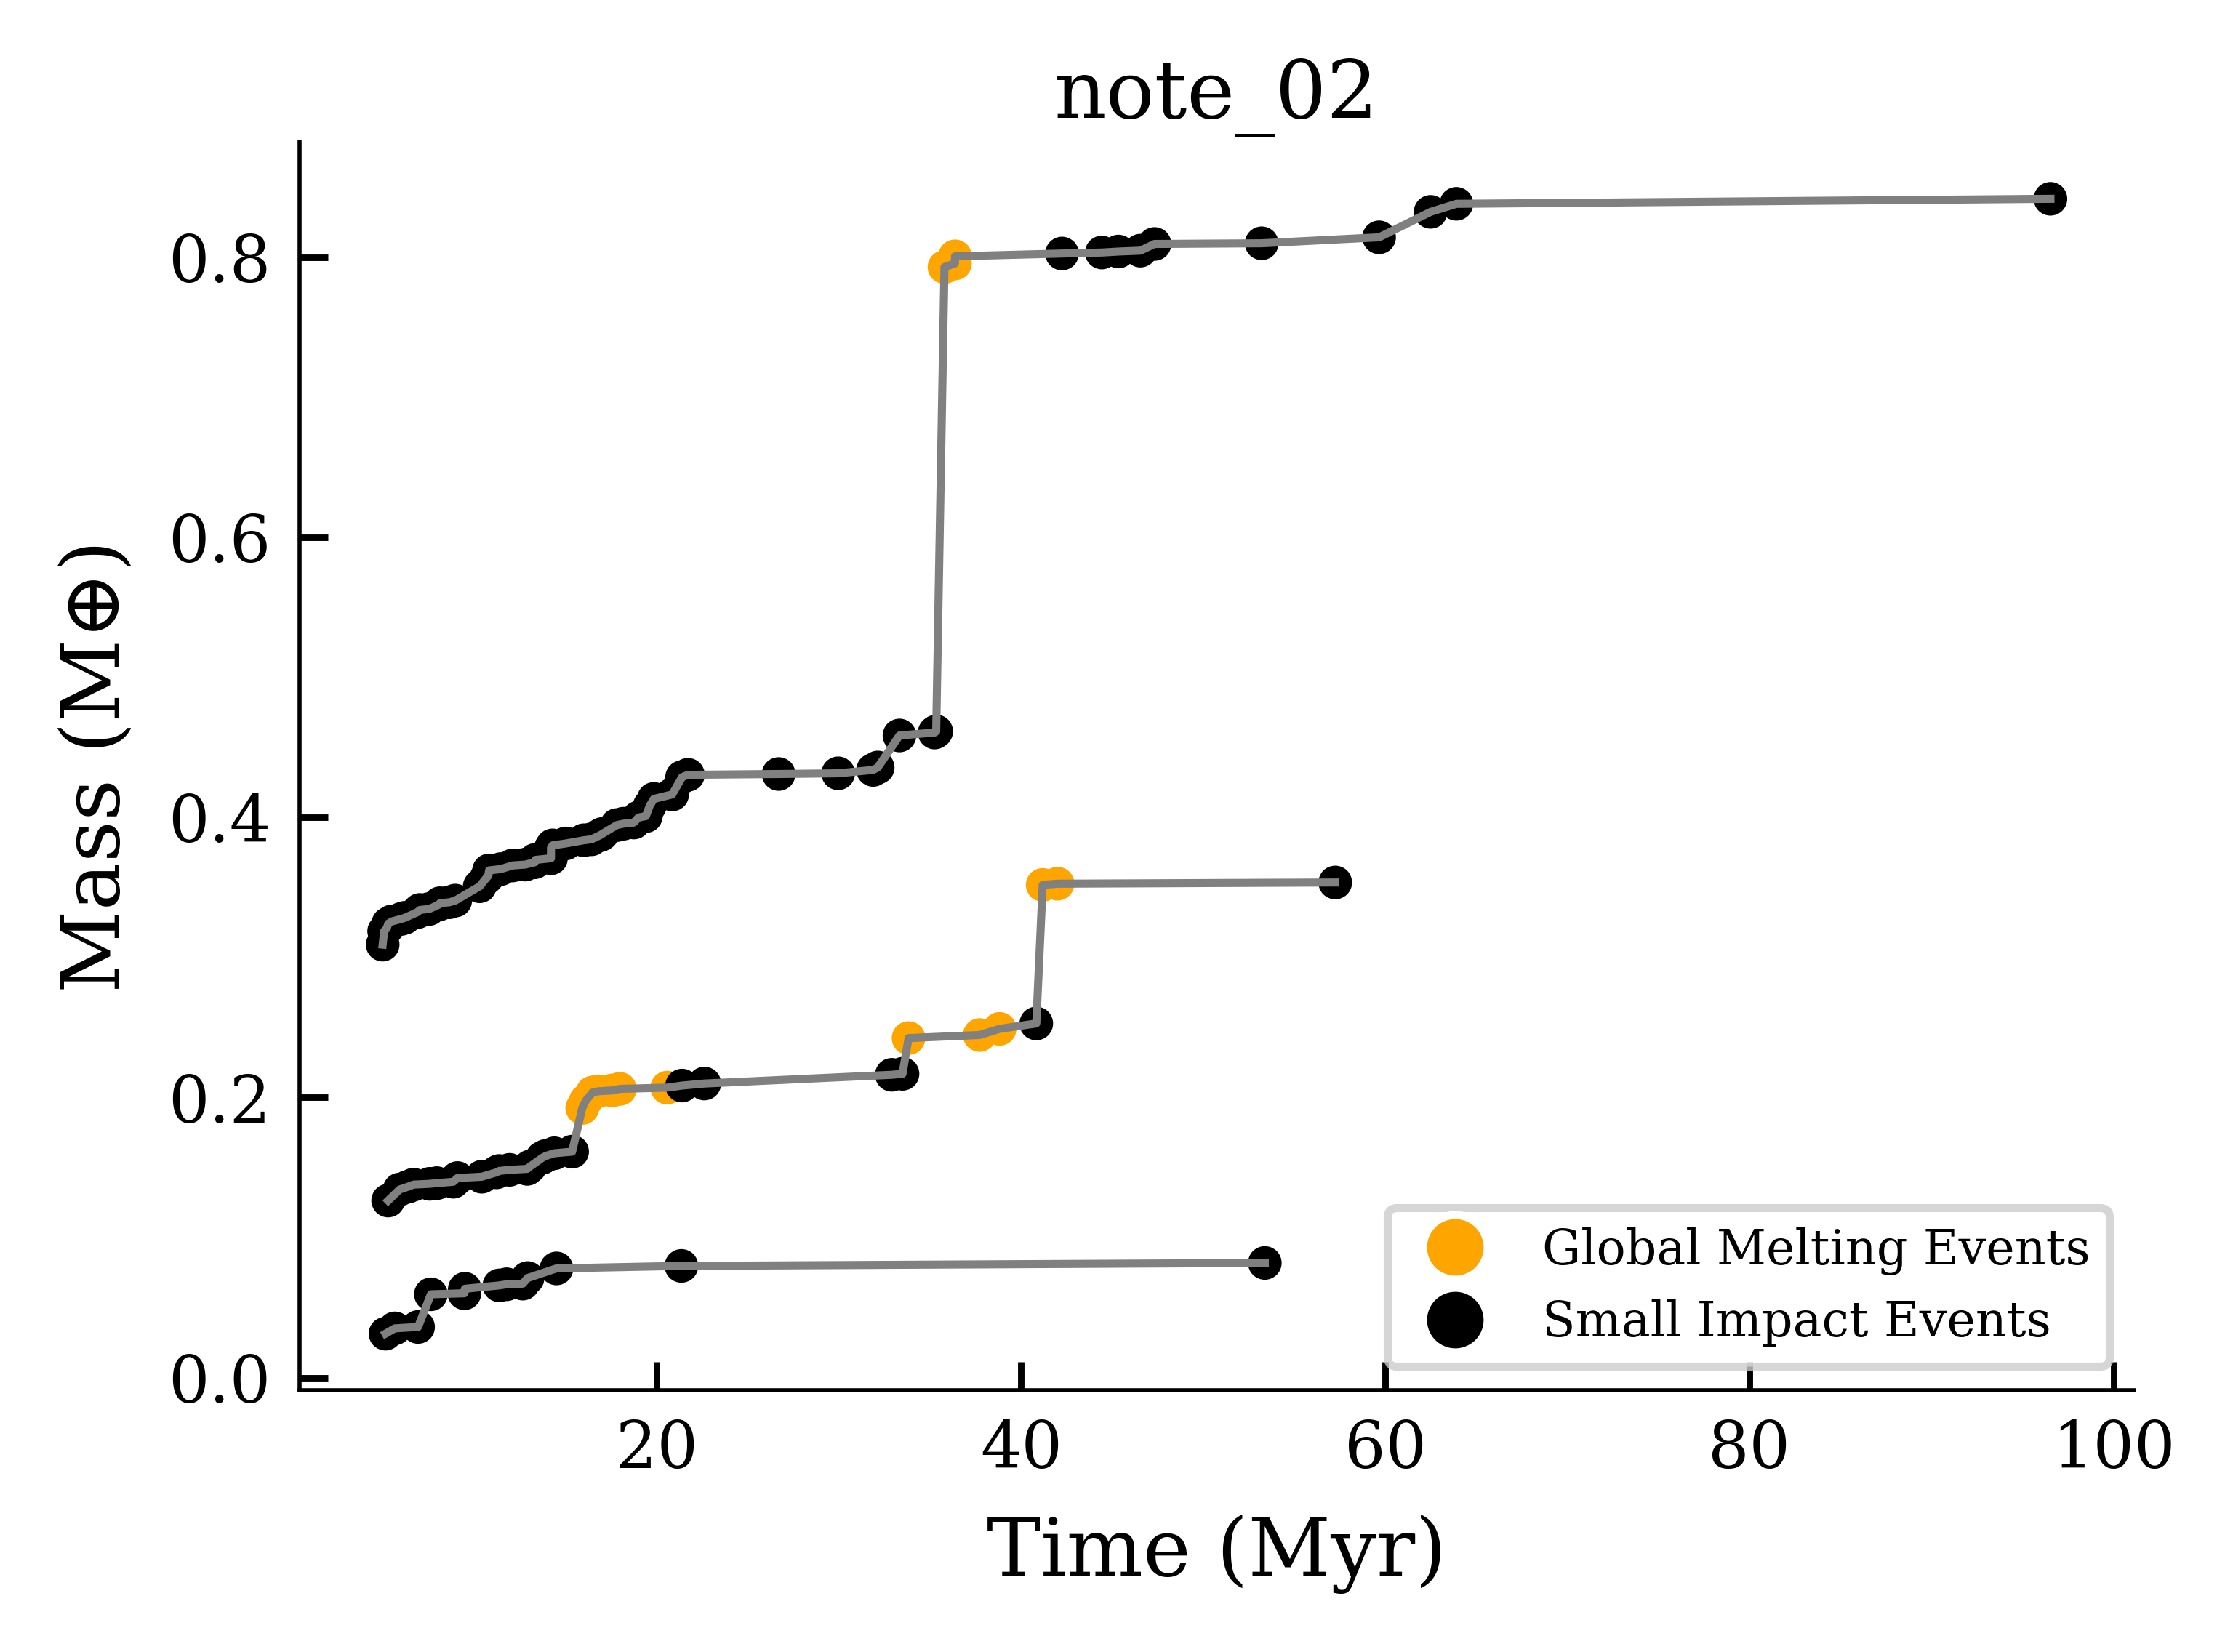

✓ Mass evolution plot displayed



In [4]:
# ============================================================================
# SECTION 3a: VISUALIZATION - MASS EVOLUTION
# ============================================================================

plt.figure(figsize=(4, 3), dpi=800)

for i in data_dict.keys():
    df1 = data_dict[i]
    planet_id = df1['target_id'].iloc[-1]
    df_planet = df1[df1['target_id'] == planet_id]
    
    x = df_planet['Time']
    y = df_planet['Mass']
    color_map = df_planet['events'].map({'small': 'black', 'global': 'orange'})
    
    # Plot continuous evolution
    plt.plot(x, y, c='grey', linewidth=1, zorder=3)
    # Mark impact events by type
    plt.scatter(x, y, c=color_map, s=10)

# ── Styling ──────────────────────────────────────────────────────
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# ── Axis labels ──────────────────────────────────────────────────
plt.title(f"{title}", fontsize=10, pad=3)
plt.xlabel("Time (Myr)", fontsize=10)
plt.ylabel("Mass (M⊕)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# ── Legend ───────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Global Melting Events',
           markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Impact Events',
           markerfacecolor='black', markersize=8)
]
plt.legend(handles=legend_handles, fontsize=6, loc='best')

plt.tight_layout()
plt.show()

print(f"✓ Mass evolution plot displayed")
print()

---
## 3b. Visualize Pressure Evolution with Impact Events

Plot equilibrium pressure (P_equil) over time, color-coded by event type:
- **Black dots** = Small impact (P = 0.6 × P_CMB)
- **Orange dots** = Global melting (higher pressure thresholds)
- **Grey line** = Pressure evolution

This reveals the **pressure conditions** under which melting events occur, 
which constrains mantle depth and thermal state during accretion.

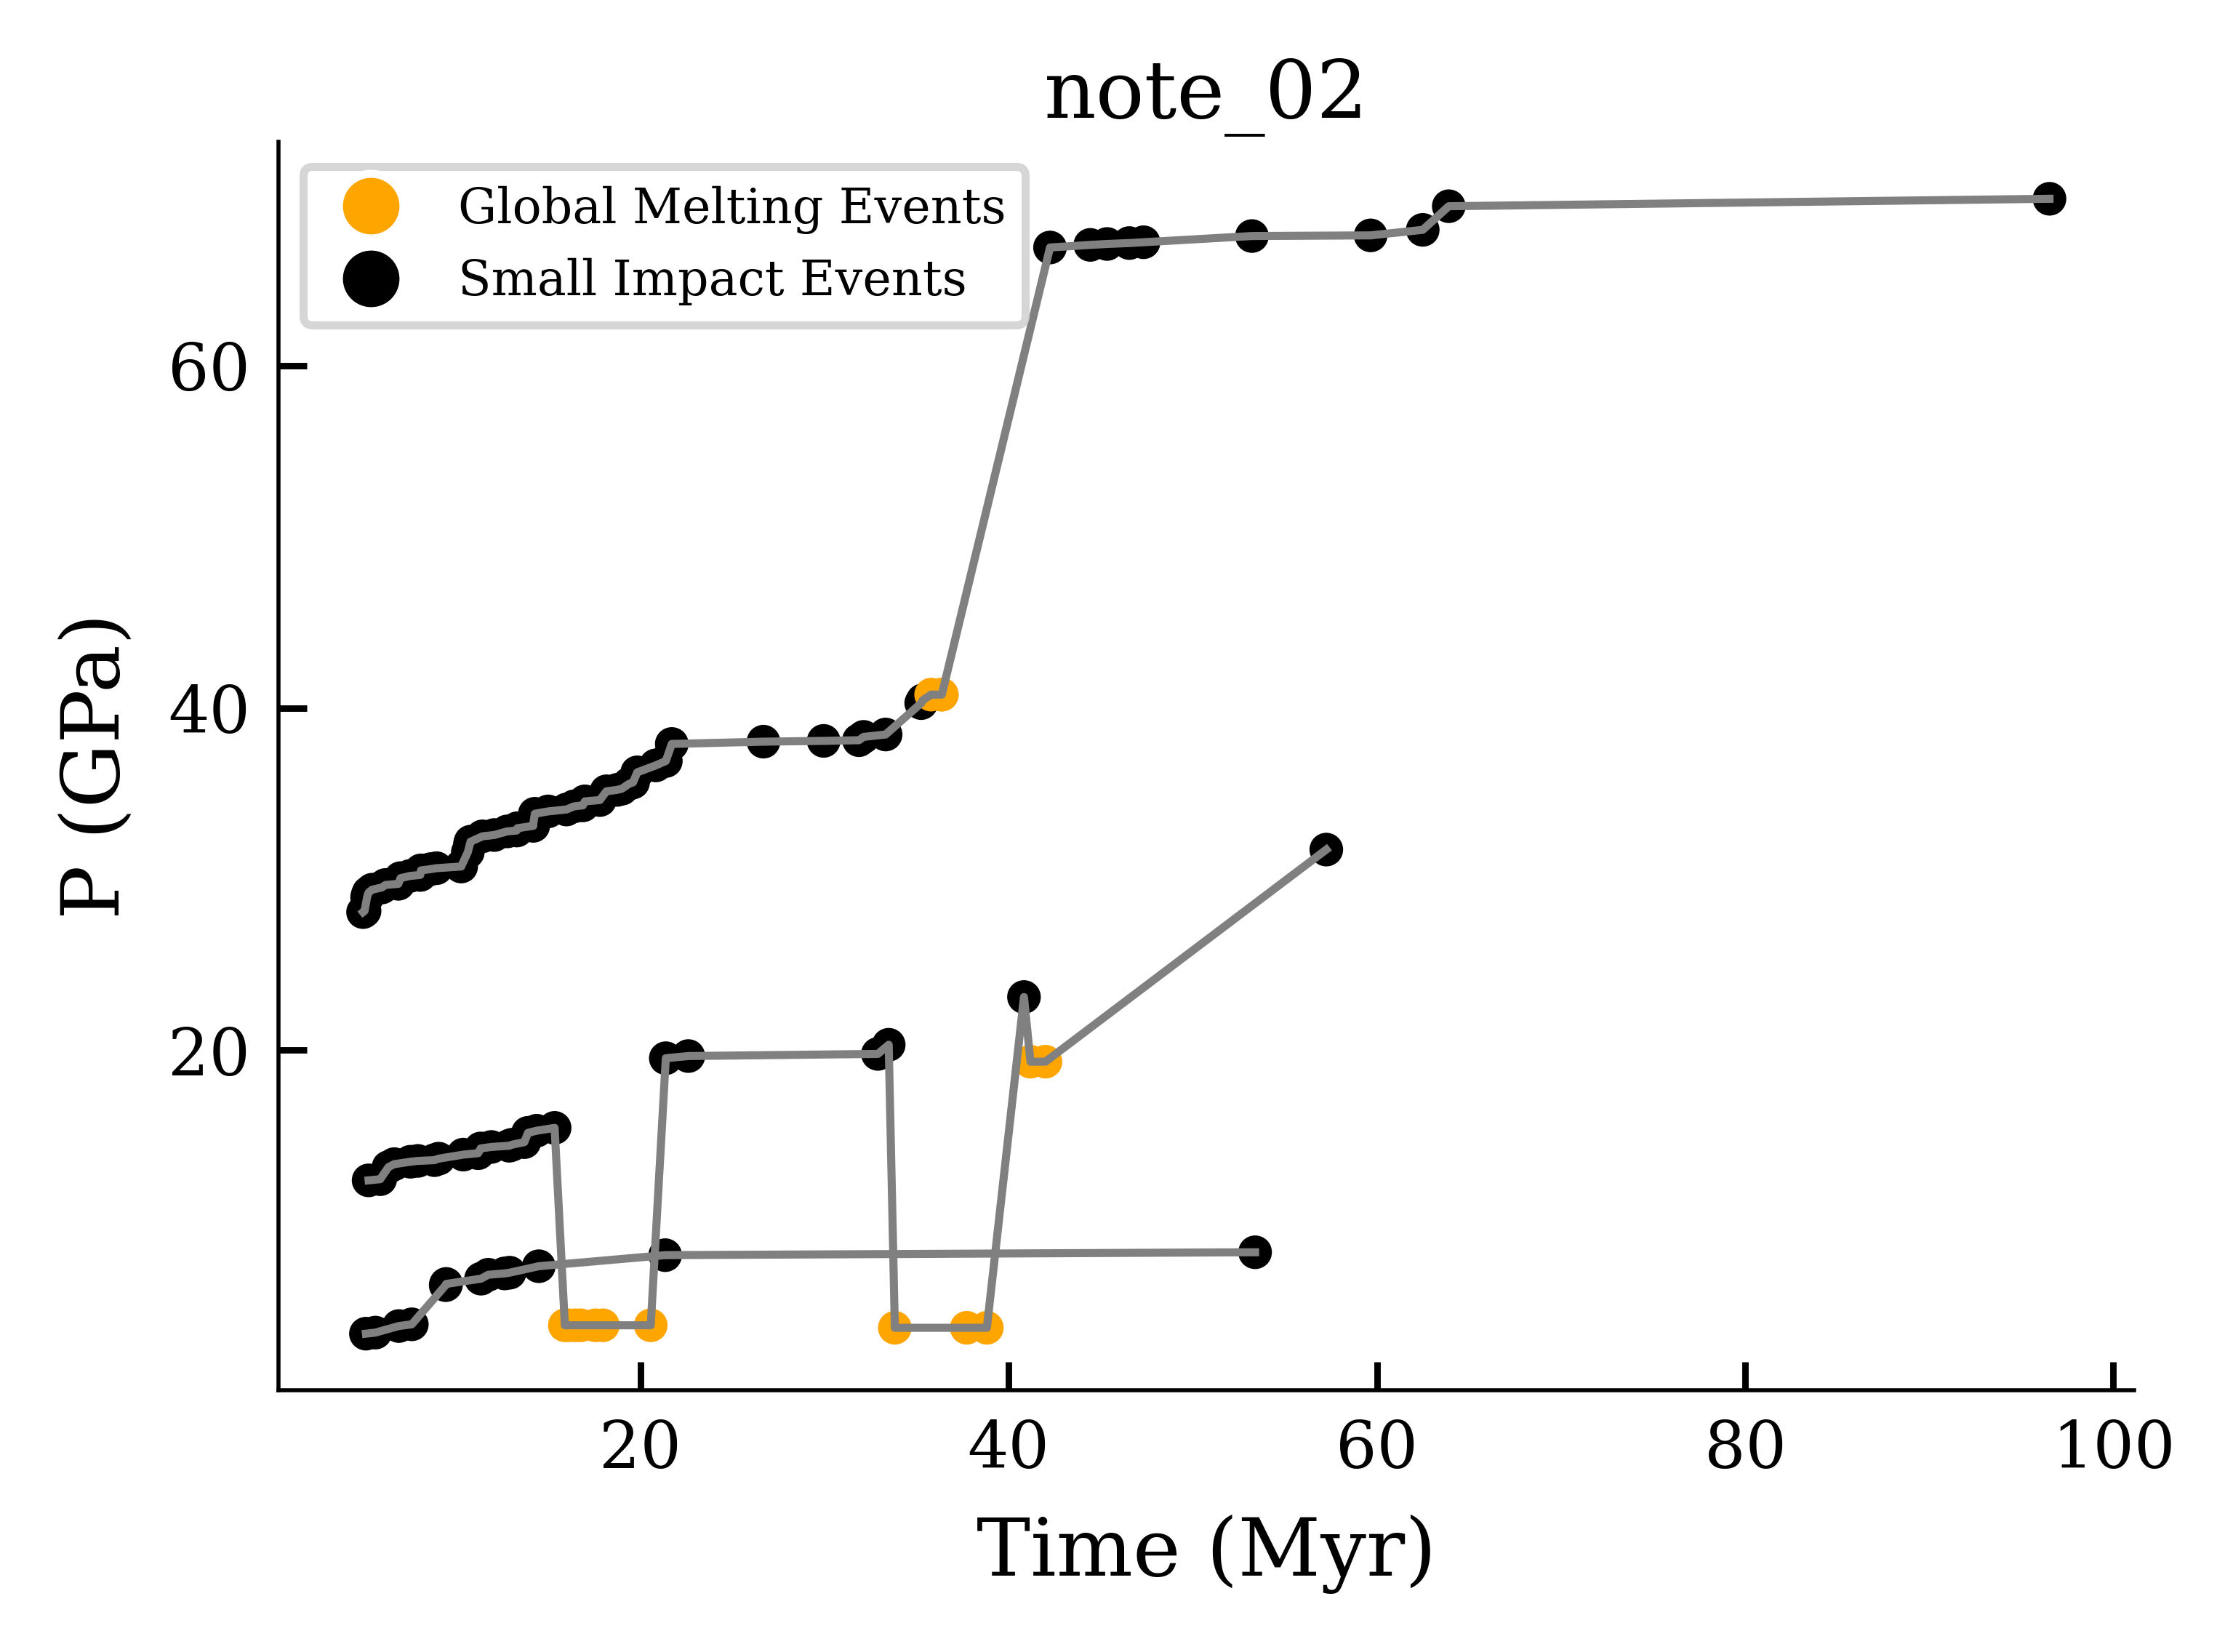

✓ Pressure evolution plot displayed



In [5]:
# ============================================================================
# SECTION 3b: VISUALIZATION - PRESSURE EVOLUTION
# ============================================================================

plt.figure(figsize=(4, 3), dpi=800)

for i in data_dict.keys():
    df1 = data_dict[i]
    planet_id = df1['target_id'].iloc[-1]
    df_planet = df1[df1['target_id'] == planet_id]
    
    x = df_planet['Time']
    y = df_planet['P_equil']  # Key column: equilibrium pressure
    color_map = df_planet['events'].map({'small': 'black', 'global': 'orange'})
    
    # Plot continuous evolution
    plt.plot(x, y, c='grey', linewidth=1, zorder=3)
    # Mark impact events by type
    plt.scatter(x, y, c=color_map, s=10)

# ── Styling ──────────────────────────────────────────────────────
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# ── Axis labels ──────────────────────────────────────────────────
plt.title(f"{title}", fontsize=10, pad=3)
plt.xlabel("Time (Myr)", fontsize=10)
plt.ylabel("P (GPa)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# ── Legend ───────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Global Melting Events',
           markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Small Impact Events',
           markerfacecolor='black', markersize=8)
]
plt.legend(handles=legend_handles, fontsize=6, loc='best')

plt.tight_layout()
plt.show()

print(f"✓ Pressure evolution plot displayed")
print()

---
## 4. Export Classified Impact Events to Excel

Save all processed datasets with event classifications to Excel file.
This preserves the complete impact history for downstream analysis.

**Output structure:**
- One sheet per original dataset (key from D)
- All original columns retained
- New column `events` contains classification: 'small' or 'global'
- New columns from global melting update (if applicable)

In [6]:
# ============================================================================
# SECTION 4: EXPORT CLASSIFIED EVENTS
# ============================================================================

save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)
save_file = f'./Tables/{Model}_small_impact.xlsx'
# ── Create output directory if needed ────────────────────────────
os.makedirs(os.path.dirname(save_file), exist_ok=True)

# ── Write all datasets to Excel ──────────────────────────────────
with pd.ExcelWriter(save_file) as writer:
    for key, df in data_dict.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"✅ Exported: {save_file}")
print(f"  Sheets    : {len(data_dict)}")
print(f"  Sheet names: {list(data_dict.keys())}")
print()

✅ Exported: ./Tables/note_02_small_impact.xlsx
  Sheets    : 3
  Sheet names: ['planets_1', 'planets_2', 'planets_3']



---
## 5. Load and Verify Exported Data

Reload the Excel file to verify export quality and inspect 
the classified impact events.

In [7]:
# ============================================================================
# SECTION 5: VERIFICATION & DATA INSPECTION
# ============================================================================

# ── Reload exported file ─────────────────────────────────────────
df_dict = pd.read_excel(save_file, sheet_name=None)

print(f"✓ Verification: Reloaded {save_file}")
print(f"  Sheets loaded: {len(df_dict)}")
print(f"  Sheet names  : {list(df_dict.keys())}")
print()

# ── Inspect a sample sheet ───────────────────────────────────────
sample_sheet = list(df_dict.keys())[0]
df_sample = df_dict[sample_sheet]

print(f"Sample sheet: {sample_sheet}")
print(f"  Rows    : {len(df_sample)}")
print(f"  Columns : {list(df_sample.columns)}")
print()

# ── Event statistics ─────────────────────────────────────────────
if 'events' in df_sample.columns:
    event_counts = df_sample['events'].value_counts()
    print(f"Event classification in {sample_sheet}:")
    for event_type, count in event_counts.items():
        print(f"  {event_type:10s}: {count:4d} ({count/len(df_sample)*100:5.1f}%)")
    print()

✓ Verification: Reloaded ./Tables/note_02_small_impact.xlsx
  Sheets loaded: 3
  Sheet names  : ['planets_1', 'planets_2', 'planets_3']

Sample sheet: planets_1
  Rows    : 142
  Columns : ['Time', 'target_id', 'impactor_id', 'm_target', 'm_impactor', 'Mass', 'Impact ratio', 'events', 'P_equil', 'T_equil', 'k_mantle']

Event classification in planets_1:
  small     :  139 ( 97.9%)
  global    :    3 (  2.1%)



---
## 6. Extract Global Melting Events (Optional)

Filter and analyze subsets of specific event types for detailed study.

**Example:** Extract all global melting events from a specific dataset.

In [8]:
# ============================================================================
# SECTION 6: EVENT SUBSET ANALYSIS (OPTIONAL)
# ============================================================================

# ── Extract global melting events from first dataset ─────────────
first_sheet = list(df_dict.keys())[0]
df_global_events = df_dict[first_sheet][df_dict[first_sheet]['events'] == 'global']

print(f"✓ Global melting events extracted from {first_sheet}:")
print(f"  Count     : {len(df_global_events)}")

if len(df_global_events) > 0:
    print(f"  Time range: {df_global_events['Time'].min():.2f} - {df_global_events['Time'].max():.2f} Myr")
    
    # Summary statistics for global events
    if 'P_equil' in df_global_events.columns:
        print(f"  Pressure  : {df_global_events['P_equil'].min():.2f} - {df_global_events['P_equil'].max():.2f} GPa")
    
    if 'Mass' in df_global_events.columns:
        print(f"  Mass      : {df_global_events['Mass'].min():.4f} - {df_global_events['Mass'].max():.4f} M⊕")

print()

# ── Extract small impact events (comparison) ─────────────────────
df_small_events = df_dict[first_sheet][df_dict[first_sheet]['events'] == 'small']

print(f"✓ Small impact events extracted from {first_sheet}:")
print(f"  Count     : {len(df_small_events)}")

if len(df_small_events) > 0:
    print(f"  Time range: {df_small_events['Time'].min():.2f} - {df_small_events['Time'].max():.2f} Myr")
    
    if 'P_equil' in df_small_events.columns:
        print(f"  Pressure  : {df_small_events['P_equil'].min():.2f} - {df_small_events['P_equil'].max():.2f} GPa")
    
    if 'Mass' in df_small_events.columns:
        print(f"  Mass      : {df_small_events['Mass'].min():.4f} - {df_small_events['Mass'].max():.4f} M⊕")

print()

print("=" * 80)
print("WORKFLOW SUMMARY: IMPACT EVENTS ANALYSIS")
print("=" * 80)
print()
print(f"Model configuration   : {config}")
print(f"Input file            : {Path_accretion_history}")
print(f"Datasets processed    : {len(data_dict)}")
print(f"Output file           : {save_file}")
print()
print("Impact event classification:")
total_events = sum((D[key].shape[0] for key in D.keys()))
total_global = len(df_dict[first_sheet][df_dict[first_sheet]['events'] == 'global'])
total_small = len(df_dict[first_sheet][df_dict[first_sheet]['events'] == 'small'])
print(f"  Total events        : {total_events}")
print(f"  Global melting      : {total_global} ({total_global/total_events*100 if total_events > 0 else 0:.1f}%)")
print(f"  Small impacts       : {total_small} ({total_small/total_events*100 if total_events > 0 else 0:.1f}%)")
print()
print("=" * 80)
print("✅ Impact event analysis complete.")
print("=" * 80)

✓ Global melting events extracted from planets_1:
  Count     : 3
  Time range: 35.79 - 36.37 Myr
  Pressure  : 40.77 - 40.77 GPa
  Mass      : 0.7929 - 0.8005 M⊕

✓ Small impact events extracted from planets_1:
  Count     : 139
  Time range: 4.93 - 96.53 Myr
  Pressure  : 0.09 - 69.74 GPa
  Mass      : 0.0011 - 0.8416 M⊕

WORKFLOW SUMMARY: IMPACT EVENTS ANALYSIS

Model configuration   : {'p_ratio': 0.6, 'Mtotal': 0.1, 'ratio': [0.1, 0.5], 'duration': 5}
Input file            : ../Accrection/Tables/note_02_collision_history.xlsx
Datasets processed    : 3
Output file           : ./Tables/note_02_small_impact.xlsx

Impact event classification:
  Total events        : 264
  Global melting      : 3 (1.1%)
  Small impacts       : 139 (52.7%)

✅ Impact event analysis complete.
